In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

Setting input parameters

In [ ]:
# Base dataset folder in Google Drive
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV created from your local preparation script
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Optional: output folder on Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_5_cnn_rgb_plus_depth")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


Building RGB + depth paths

In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["depth_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "depth_raw.png")
)

# Check existence
df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())
df["depth_exists"] = df["depth_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:  ", (~df["rgb_exists"]).sum())
print("Missing depth images:", (~df["depth_exists"]).sum())

# Keep only rows where both exist
df = df[df["rgb_exists"] & df["depth_exists"]].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print(df.head())

Missing RGB images:   0
Missing depth images: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                            rgb_path  \
0  /content/drive/MyDrive/Speciale/dataset/nutrit...   
1  /content/drive/MyDrive/Speciale/dataset/nutrit...   
2  /content/drive/MyDrive/Speciale/dataset/nutrit...   
3  /content/drive/MyDrive/Speciale/dataset/nutrit...   
4  /content/drive/MyDrive/Speciale/dataset/nutrit...   

                                          depth_path  rgb_exists  depth_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...        True          True  
1  /content/drive/MyDrive/Spec

Creating Train / Validation / Test splits

In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2420
Val:   334
Test:  507


Setting model parameters

In [ ]:
IMG_HEIGHT = 640
IMG_WIDTH = 480
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

Data loader

In [ ]:
def load_rgb_image(rgb_path):
    rgb = tf.io.read_file(rgb_path)
    rgb = tf.image.decode_png(rgb, channels=3)
    rgb = tf.image.resize(rgb, [IMG_HEIGHT, IMG_WIDTH])
    rgb = tf.cast(rgb, tf.float32)
    return rgb


def load_depth_image(depth_path):
    """
    Loads raw depth image as 1-channel.
    Assumes depth_raw.png is stored as uint16.
    Depth is normalized to [0,1] by dividing by 65535.
    """
    depth = tf.io.read_file(depth_path)

    depth = tf.image.decode_png(depth, channels=1, dtype=tf.uint16)

    # Resize depth map
    depth = tf.image.resize(depth, [IMG_HEIGHT, IMG_WIDTH], method="nearest")

    # Convert to float32
    depth = tf.cast(depth, tf.float32)

    # Normalize depth to [0,1]
    depth = depth / 65535.0

    return depth


def load_rgb_depth_and_label(rgb_path, depth_path, label):
    rgb = load_rgb_image(rgb_path)
    depth = load_depth_image(depth_path)
    label = tf.cast(label, tf.float32)

    return {
        "rgb_input": rgb,
        "depth_input": depth
    }, label

In [ ]:
def make_dataset(dataframe, batch_size=8, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    depth_paths = dataframe["depth_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, depth_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_depth_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Checking that both RGB and depth images has been created correctly

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:   ", batch_inputs["rgb_input"].shape)
    print("Depth batch shape: ", batch_inputs["depth_input"].shape)
    print("Labels batch shape:", batch_labels.shape)

RGB batch shape:    (16, 640, 480, 3)
Depth batch shape:  (16, 640, 480, 1)
Labels batch shape: (16,)


It should be 640x480x3 and 640x480x1

In [ ]:
from pathlib import Path
import os

def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)
df["depth_size"] = df["depth_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] == 0).sum())
print("Empty depth files:", (df["depth_size"] == 0).sum())

print("\nExample empty RGB files:")
print(df.loc[df["rgb_size"] == 0, ["dish_id", "rgb_path"]].head())

print("\nExample empty depth files:")
print(df.loc[df["depth_size"] == 0, ["dish_id", "depth_path"]].head())

Empty RGB files: 0
Empty depth files: 1

Example empty RGB files:
Empty DataFrame
Columns: [dish_id, rgb_path]
Index: []

Example empty depth files:
              dish_id                                         depth_path
2280  dish_1564159636  /content/drive/MyDrive/Speciale/dataset/nutrit...


In [ ]:
df["rgb_size"] = df["rgb_path"].apply(lambda p: Path(p).stat().st_size if Path(p).exists() else -1)
df["depth_size"] = df["depth_path"].apply(lambda p: Path(p).stat().st_size if Path(p).exists() else -1)

df = df[
    (df["rgb_exists"]) &
    (df["depth_exists"]) &
    (df["rgb_size"] > 0) &
    (df["depth_size"] > 0)
].copy()

print("Remaining samples after removing empty files:")
print(df["split"].value_counts())

Remaining samples after removing empty files:
split
train    2420
test      507
val       334
Name: count, dtype: int64


The two previous code blocks were created due the model throwing an error during training. The reason was due to one dish not having a proper depth_raw.png file, or it atleast had a value of 0 so that had to be removed before training of the network could proceed.

Model architecture

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0

# =========================================================
# RGB pretrained backbone
# =========================================================
rgb_base = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
rgb_base.trainable = False

# =========================================================
# RGB input branch
# =========================================================
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

rgb_x = keras.applications.efficientnet_v2.preprocess_input(rgb_input)
rgb_feat = rgb_base(rgb_x, training=False)   # keep spatial feature map

# =========================================================
# Depth input branch -> guidance mask
# Using depth_input shape=(H,W,1) for raw depth (black and white images)
# =========================================================
depth_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name="depth_input")

depth_x = layers.Rescaling(1.0 / 255.0, name="depth_rescale")(depth_input)

# Small depth guidance CNN
depth_x = layers.Conv2D(16, 3, padding="same", use_bias=False, name="depth_conv1")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn1")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu1")(depth_x)
depth_x = layers.MaxPooling2D(2, name="depth_pool1")(depth_x)

depth_x = layers.Conv2D(32, 3, padding="same", use_bias=False, name="depth_conv2")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn2")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu2")(depth_x)
depth_x = layers.MaxPooling2D(2, name="depth_pool2")(depth_x)

depth_x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="depth_conv3")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn3")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu3")(depth_x)
depth_x = layers.MaxPooling2D(2, name="depth_pool3")(depth_x)

depth_x = layers.Conv2D(128, 3, padding="same", use_bias=False, name="depth_conv4")(depth_x)
depth_x = layers.BatchNormalization(name="depth_bn4")(depth_x)
depth_x = layers.Activation("relu", name="depth_relu4")(depth_x)

# Convert depth features into a single spatial attention mask
depth_mask = layers.Conv2D(1, 1, padding="same", activation="sigmoid", name="depth_mask")(depth_x)

# =========================================================
# Resize mask to match RGB feature map size
# =========================================================
def resize_mask_to_rgb(inputs):
    mask, rgb = inputs
    target_size = tf.shape(rgb)[1:3]
    return tf.image.resize(mask, target_size, method="bilinear")

depth_mask_resized = layers.Lambda(
    resize_mask_to_rgb,
    name="resize_depth_mask"
)([depth_mask, rgb_feat])

# =========================================================
# Depth-guided RGB modulation
# Residual-style gating is safer than pure multiplication
# gated_rgb = rgb_feat * (1 + mask)
# =========================================================
one_plus_mask = layers.Lambda(lambda m: 1.0 + m, name="one_plus_mask")(depth_mask_resized)
gated_rgb_feat = layers.Multiply(name="depth_guided_rgb")([rgb_feat, one_plus_mask])

# =========================================================
# Regression head
# =========================================================
x = layers.GlobalAveragePooling2D(name="rgb_guided_gap")(gated_rgb_feat)

# optional: also include a pooled summary of the mask itself
mask_summary = layers.GlobalAveragePooling2D(name="mask_gap")(depth_mask_resized)
x = layers.Concatenate(name="fusion_concat")([x, mask_summary])

x = layers.Dense(256, activation="relu", name="fusion_dense_1")(x)
x = layers.Dropout(0.3, name="fusion_dropout_1")(x)

x = layers.Dense(128, activation="relu", name="fusion_dense_2")(x)
x = layers.Dropout(0.2, name="fusion_dropout_2")(x)

output = layers.Dense(1, activation="linear", name="carb_output")(x)

# =========================================================
# Final model
# =========================================================
model = keras.Model(
    inputs=[rgb_input, depth_input],
    outputs=output,
    name="efficientnetv2b0_rgb_depth_guided_gating"
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "efficientnetv2b0_rgb_depth_guided_gating"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ depth_input         │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_rescale       │ (None, 640, 480,  │          0 │ depth_input[0][0] │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv1         │ (None, 640, 480,  │        144 │ depth_rescale[0]… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn1           │ (None, 640, 480,  │         64 │ depth_conv1[0][0] │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu1         │ (None, 640, 480,  │          0 │ depth_bn1[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_pool1         │ (None, 320, 240,  │          0 │ depth_relu1[0][0] │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv2         │ (None, 320, 240,  │      4,608 │ depth_pool1[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn2           │ (None, 320, 240,  │        128 │ depth_conv2[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu2         │ (None, 320, 240,  │          0 │ depth_bn2[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_pool2         │ (None, 160, 120,  │          0 │ depth_relu2[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv3         │ (None, 160, 120,  │     18,432 │ depth_pool2[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn3           │ (None, 160, 120,  │        256 │ depth_conv3[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_relu3         │ (None, 160, 120,  │          0 │ depth_bn3[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_pool3         │ (None, 80, 60,    │          0 │ depth_relu3[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_conv4         │ (None, 80, 60,    │     73,728 │ depth_pool3[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_bn4           │ (None, 80, 60,    │        512 │ depth_conv4[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_input           │ (None, 640, 480,  │          0 │ -               

 Total params: 6,378,530 (24.33 MB)

 Trainable params: 458,738 (1.75 MB)

 Non-trainable params: 5,919,792 (22.58 MB)

The idea behind this is to not have a seperate model for the depth it is instead treated as a mask for the RGB images, meaning that we tell the model through a small depth CNN where to look, so the regions of the images with a lot of food in them will get larger attention to them. The idea comes from this paper: https://www.ecva.net/papers/eccv_2018/papers_ECCV/papers/Weiyue_Wang_Depth-aware_CNN_for_ECCV_2018_paper.pdf

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

Training model

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=300,
    callbacks=callbacks
)

Epoch 1/300
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 781.4583 - mae: 12.3728 - mse: 781.4583 
Epoch 1: val_loss improved from None to 132.96895, saving model to /content/drive/MyDrive/Speciale/Models/Model_5_cnn_rgb_plus_depth/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_5_cnn_rgb_plus_depth/best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 2167s 14s/step - loss: 468.2000 - mae: 10.6182 - mse: 468.2000 - val_loss: 132.9689 - val_mae: 8.0131 - val_mse: 132.9689 - learning_rate: 0.0010
Epoch 2/300
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - loss: 165.9797 - mae: 8.0045 - mse: 165.9797
Epoch 2: val_loss improved from 132.96895 to 114.83392, saving model to /content/drive/MyDrive/Speciale/Models/Model_5_cnn_rgb_plus_depth/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_5_cnn_rgb_plus_depth/best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 73s 481ms/step - loss: 407.1954 - mae: 8.3566 - mse

Visualizing training and validation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Loss
    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # MAE
    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)
    else:
        axes[1].set_visible(False)

    # MSE
    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

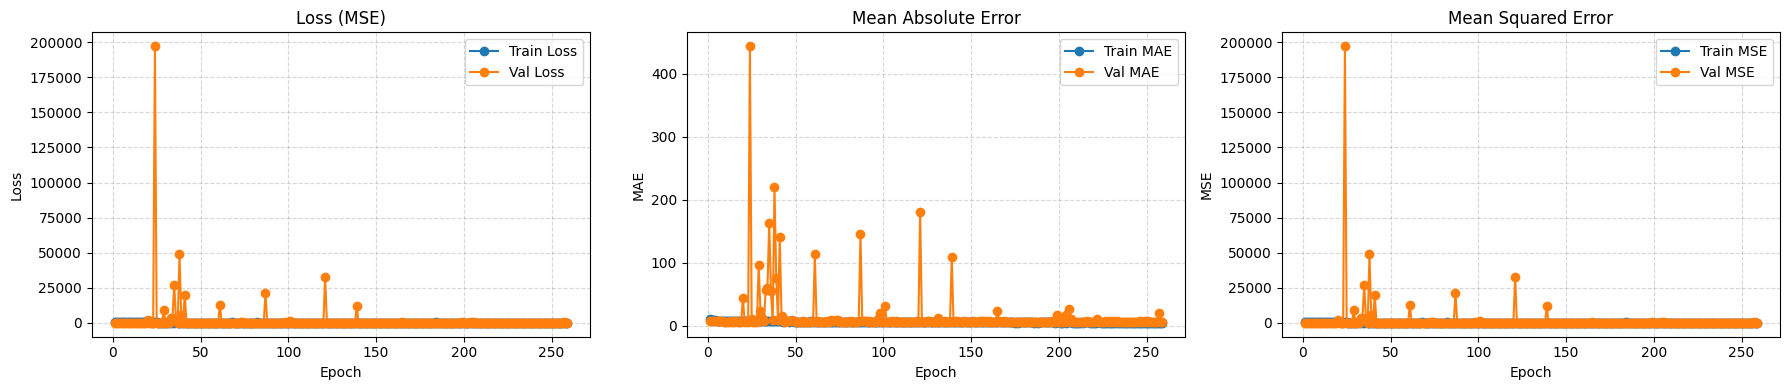

Best val_loss: 57.0169 at epoch 109
Val MAE at best epoch: 5.4235
Val MSE at best epoch: 57.0169


In [ ]:
plot_metrics(history)

Evaluating on test set

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 408s 13s/step - loss: 86.1413 - mae: 6.3139 - mse: 86.1413
{'loss': 86.14126586914062, 'mae': 6.313889980316162, 'mse': 86.14126586914062}
